## Data Loading and Preparation

In [3]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

X, y = load_diabetes(return_X_y=True)
X = X[:, [2]] #  Use only one feature (column 2)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=20,        # test size can accept either a fraction or an integer (exact number)
    shuffle=False
) 


## Linear regression model

In [4]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression().fit(X_train, y_train)

## Model evaluation

In [5]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)

print(f"Mean squared error: {mse:.2f}")
print(f"Coefficient of determination: {R2:.2f}")

Mean squared error: 2548.07
Coefficient of determination: 0.47


## Plotting the results

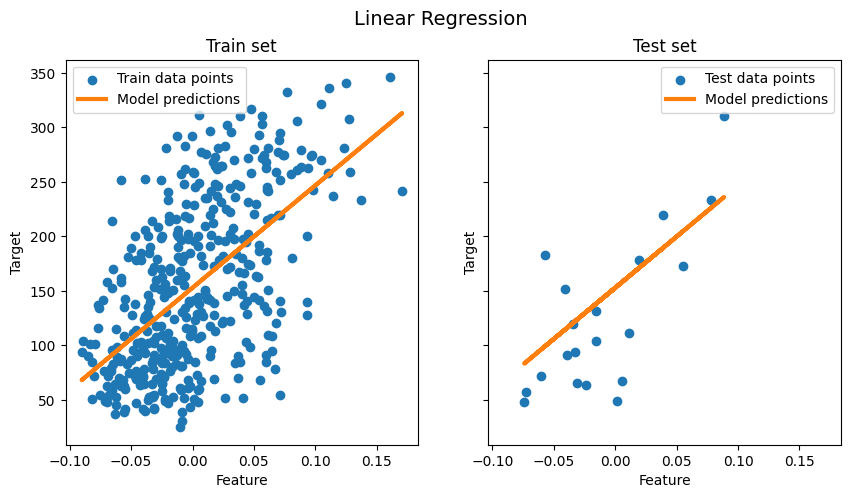

In [9]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    ncols=2,
    figsize=(10,5),
    sharex=True,
    sharey=True,
    
)

ax[0].scatter(X_train, y_train, label="Train data points")
ax[0].plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)

ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test, y_test, label="Test data points")
ax[1].plot(
    X_test,
    y_pred,
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression", fontsize=14)
plt.show()

## Ordinary Least Squares and Ridge Regression Varaince

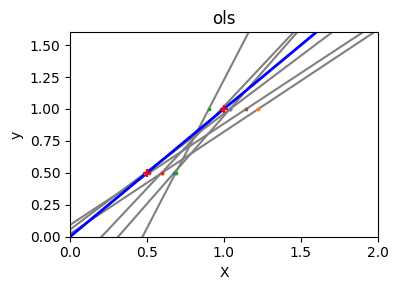

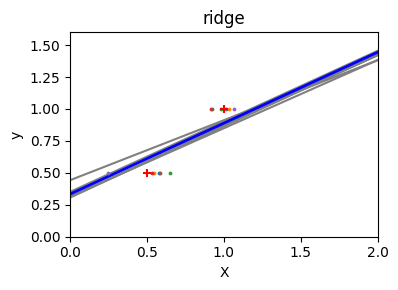

In [10]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import linear_model

X_train = np.c_[0.5, 1.].T
y_train = [0.5, 1]
X_test = np.c_[0, 2].T

np.random.seed(0)

classifiers = dict(
    ols=linear_model.LinearRegression(), ridge=linear_model.Ridge(alpha=0.1)
)

for name , clf in classifiers.items():
    fig, ax = plt.subplots(figsize=(4, 3))

    for _ in range(6):
        this_X = 0.1 * np.random.normal(size=(2, 1,)) + X_train
        clf.fit(this_X, y_train)

        ax.plot(X_test, clf.predict(X_test), color="gray")
        ax.scatter(this_X, y_train, s=3, marker="o", zorder=10)
    
    clf.fit(X_train, y_train)
    ax.plot(X_test, clf.predict(X_test), linewidth=2, color="blue")
    ax.scatter(X_train, y_train, s=30, c="red", marker="+", zorder=10)

    ax.set(title=name, xlim=(0, 2), ylim=(0, 1.6), xlabel="X", ylabel="y")

    fig.tight_layout()

plt.show()

